# Malaria Cell Classification - Data Understanding

## Objective

The objective of this notebook is to understand the malaria cell image dataset before any preprocessing or model development.

The notebook will answer the following questions:

- What is the folder structure?
- How many classes are present?
- How many images belong to each class?
- Are the classes balanced?
- What image formats are available?
- What are the image dimensions?
- Are there corrupted images?
- What does the data look like visually?

Understanding these characteristics helps determine the preprocessing pipeline and informs model design decisions.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Malaria-Cell-Classification"
)

DATASET_DIR = PROJECT_DIR / "dataset"
DATASET_ZIP = DATASET_DIR / "data.zip"

print(PROJECT_DIR)
print(DATASET_ZIP)

/content/drive/MyDrive/Malaria-Cell-Classification
/content/drive/MyDrive/Malaria-Cell-Classification/dataset/data.zip


In [7]:
import zipfile

from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

In [8]:
EXTRACT_DIR = DATASET_DIR / "cell_images"

if not EXTRACT_DIR.exists():

    with zipfile.ZipFile(DATASET_ZIP, "r") as zip_ref:
        zip_ref.extractall(DATASET_DIR)

print("Dataset Ready")

Dataset Ready


In [9]:
import os

for item in os.listdir(EXTRACT_DIR):
    print(item)

Parasitized
Uninfected


## 4. Dataset Size and Class Distribution

Before training a classification model, it is important to determine whether the dataset is balanced.

A balanced dataset contains approximately the same number of samples for each class. If one class has significantly more images than the other, the model may become biased toward the majority class.

In this section, we count the number of images in each class and compute the percentage distribution.

In [11]:
# Dataset Class Distribution

# Paths to each class
parasitized_path = EXTRACT_DIR / "Parasitized"
uninfected_path = EXTRACT_DIR / "Uninfected"

# Count valid image files
VALID_EXTENSIONS = {".png", ".jpg", ".jpeg"}

num_parasitized = sum(
    1 for image in parasitized_path.iterdir()
    if image.suffix.lower() in VALID_EXTENSIONS
)

num_uninfected = sum(
    1 for image in uninfected_path.iterdir()
    if image.suffix.lower() in VALID_EXTENSIONS
)

print(f"Parasitized Images : {num_parasitized:,}")
print(f"Uninfected Images  : {num_uninfected:,}")
print(f"Total Images       : {num_parasitized + num_uninfected:,}")

Parasitized Images : 13,779
Uninfected Images  : 13,779
Total Images       : 27,558
Parasitized Images : 13,779
Uninfected Images  : 13,779
Total Images       : 27,558


In [13]:
total_images = num_parasitized + num_uninfected

print(f"Parasitized : {100 * num_parasitized / total_images:.2f}%")
print(f"Uninfected  : {100 * num_uninfected / total_images:.2f}%")

Parasitized : 50.00%
Uninfected  : 50.00%


In [14]:
import pandas as pd

class_summary = pd.DataFrame({
    "Class": ["Parasitized", "Uninfected"],
    "Number of Images": [num_parasitized, num_uninfected]
})

class_summary["Percentage"] = (
    class_summary["Number of Images"] / total_images * 100
).round(2)

class_summary

,Class,Number of Images,Percentage
0,Parasitized,13779,50.0
1,Uninfected,13779,50.0


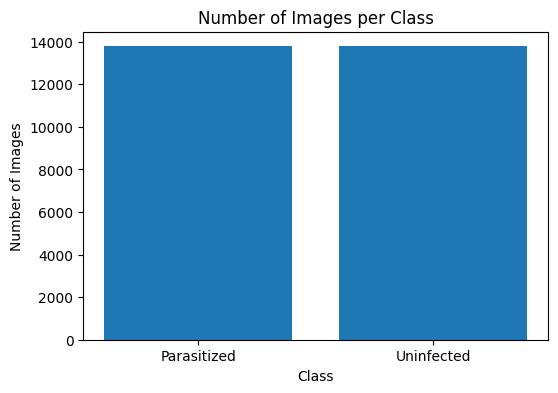

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    class_summary["Class"],
    class_summary["Number of Images"]
)

plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

### Observations

- The dataset contains two classes: **Parasitized** and **Uninfected**.
- The number of images in each class is nearly identical.
- Therefore, the dataset is **balanced**, meaning each class contributes approximately 50% of the total images.
- Since the dataset is balanced, we do not anticipate the need for techniques such as class weighting, oversampling, or undersampling during model training.
- We will still use **stratified splitting** when creating the training, validation, and test sets to preserve this balance across all subsets.

## 5. Image File Inspection

Before preprocessing the images, we inspect the dataset to determine:

- the image file formats,
- whether all files are valid images,
- and whether any unexpected or corrupted files are present.

This helps prevent errors during model training.

In [16]:
from collections import Counter

# Image File Types


extensions = Counter()

# Iterate through every class directory
for class_folder in EXTRACT_DIR.iterdir():

    if not class_folder.is_dir():
        continue

    for image_path in class_folder.iterdir():

        if image_path.is_file():
            extensions[image_path.suffix.lower()] += 1

print("Image File Types")
print("-" * 30)

for extension, count in extensions.items():
    print(f"{extension:<8} : {count:,}")

Image File Types
------------------------------
.png     : 27,558
.db      : 2


### Observations

- The dataset primarily consists of PNG images.
- Two `.db` files were found within the dataset.
- These are likely `Thumbs.db` files automatically generated by Microsoft Windows and are not image data.
- These files will be excluded during preprocessing to prevent image loading errors.

## 6. Image Dimensions

Image dimensions are an important characteristic of an image dataset.

Neural networks require images of a fixed size as input. Therefore, before defining a preprocessing pipeline, we inspect the dimensions of every image in the dataset.

Specifically, we determine:

- Minimum image width and height
- Maximum image width and height
- Average image width and height
- Whether all images share the same dimensions

In [18]:

# Collect Image Dimensions


widths = []
heights = []
image_sizes = []

VALID_EXTENSIONS = {".png", ".jpg", ".jpeg"}

# Iterate through every class directory
for class_folder in EXTRACT_DIR.iterdir():

    if not class_folder.is_dir():
        continue

    for image_path in class_folder.iterdir():

        if (
            not image_path.is_file()
            or image_path.suffix.lower() not in VALID_EXTENSIONS
        ):
            continue

        with Image.open(image_path) as img:

            width, height = img.size

            widths.append(width)

            heights.append(height)

            image_sizes.append((width, height))

In [19]:

print(f"Minimum Width : {min(widths)}")
print(f"Maximum Width : {max(widths)}")
print(f"Average Width : {np.mean(widths):.2f}")

print()

print(f"Minimum Height : {min(heights)}")
print(f"Maximum Height : {max(heights)}")
print(f"Average Height : {np.mean(heights):.2f}")

Minimum Width : 46
Maximum Width : 394
Average Width : 132.49

Minimum Height : 40
Maximum Height : 385
Average Height : 132.98


In [20]:
unique_sizes = set(image_sizes)

print(f"Number of unique image dimensions: {len(unique_sizes)}")

Number of unique image dimensions: 1627


In [21]:
print("Unique image dimensions:")

for size in sorted(unique_sizes):
    print(size)

Unique image dimensions:
(46, 79)
(49, 58)
(55, 40)
(58, 52)
(58, 100)
(58, 109)
(61, 61)
(61, 70)
(61, 79)
(61, 94)
(64, 49)
(64, 58)
(64, 70)
(64, 73)
(64, 76)
(64, 103)
(67, 58)
(67, 70)
(67, 79)
(67, 136)
(70, 46)
(70, 73)
(70, 76)
(70, 79)
(70, 82)
(70, 85)
(70, 91)
(70, 94)
(73, 70)
(73, 73)
(73, 79)
(73, 85)
(73, 88)
(73, 94)
(73, 97)
(73, 100)
(73, 106)
(73, 124)
(76, 55)
(76, 58)
(76, 70)
(76, 73)
(76, 82)
(76, 85)
(76, 88)
(76, 91)
(76, 94)
(76, 106)
(76, 115)
(76, 127)
(76, 142)
(76, 166)
(79, 61)
(79, 70)
(79, 73)
(79, 76)
(79, 79)
(79, 82)
(79, 85)
(79, 88)
(79, 91)
(79, 97)
(79, 100)
(79, 103)
(79, 106)
(79, 109)
(79, 115)
(79, 130)
(79, 139)
(79, 157)
(82, 76)
(82, 82)
(82, 85)
(82, 88)
(82, 91)
(82, 94)
(82, 97)
(82, 100)
(82, 103)
(82, 106)
(82, 109)
(82, 112)
(82, 118)
(82, 121)
(85, 70)
(85, 73)
(85, 76)
(85, 79)
(85, 82)
(85, 85)
(85, 88)
(85, 91)
(85, 94)
(85, 97)
(85, 100)
(85, 103)
(85, 106)
(85, 109)
(85, 112)
(85, 115)
(85, 118)
(85, 121)
(85, 127)
(85, 130)
(8

In [22]:
dimension_summary = {
    "Statistic": [
        "Minimum Width",
        "Maximum Width",
        "Average Width",
        "Minimum Height",
        "Maximum Height",
        "Average Height",
        "Unique Dimensions"
    ],
    "Value": [
        min(widths),
        max(widths),
        round(np.mean(widths), 2),
        min(heights),
        max(heights),
        round(np.mean(heights), 2),
        len(unique_sizes)
    ]
}

import pandas as pd

pd.DataFrame(dimension_summary)

,Statistic,Value
0,Minimum Width,46.00
1,Maximum Width,394.00
2,Average Width,132.49
3,Minimum Height,40.00
4,Maximum Height,385.00
5,Average Height,132.98
6,Unique Dimensions,1627.00


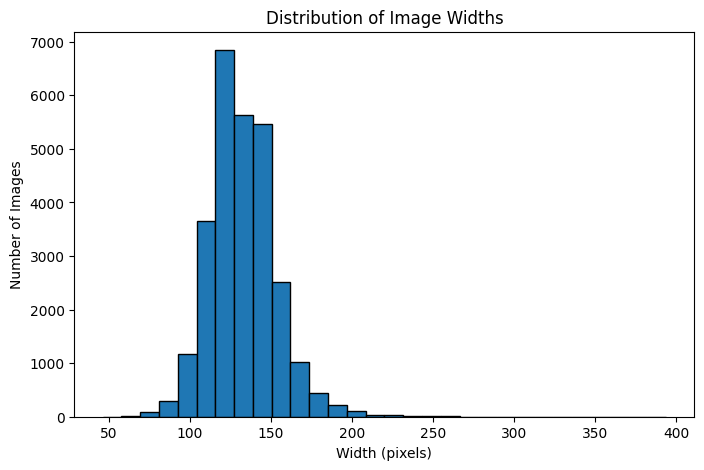

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(widths, bins=30, edgecolor='black')

plt.title("Distribution of Image Widths")
plt.xlabel("Width (pixels)")
plt.ylabel("Number of Images")

plt.show()

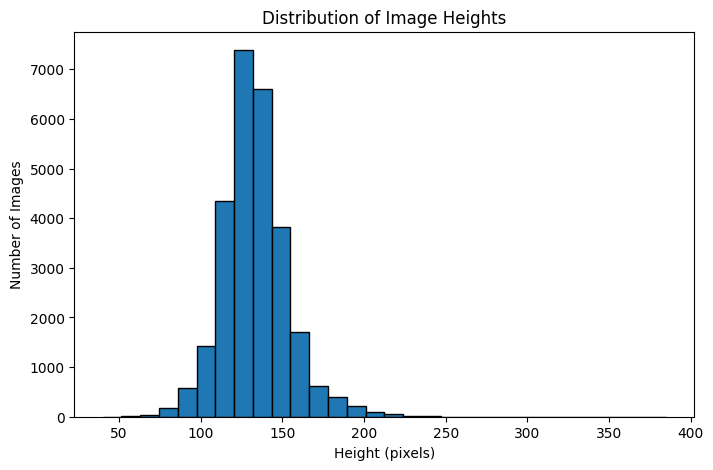

In [24]:
plt.figure(figsize=(8,5))
plt.hist(heights, bins=30, edgecolor='black')

plt.title("Distribution of Image Heights")
plt.xlabel("Height (pixels)")
plt.ylabel("Number of Images")

plt.show()

## 7. Image Color Channels

In addition to image dimensions, we inspect the image color mode.

This helps determine:

- Whether the images are grayscale or RGB.
- The number of channels expected by the neural network.
- Whether color information should be preserved during preprocessing.

Since malaria parasites are identified partly by their staining characteristics, preserving color information may improve classification performance.

In [25]:
image_modes = Counter()

VALID_EXTENSIONS = {".png", ".jpg", ".jpeg"}

# Iterate through every class directory
for class_folder in EXTRACT_DIR.iterdir():

    if not class_folder.is_dir():
        continue

    for image_path in class_folder.iterdir():

        if (
            not image_path.is_file()
            or image_path.suffix.lower() not in VALID_EXTENSIONS
        ):
            continue

        with Image.open(image_path) as img:
            image_modes[img.mode] += 1

print("Image Color Modes")
print("-" * 30)

for mode, count in image_modes.items():
    print(f"{mode:<5} : {count:,}")

Image Color Modes
------------------------------
RGB   : 27,558


### Observations

#### Image Dimensions

- Image widths range from **46** to **394** pixels.
- Image heights range from **40** to **385** pixels.
- Although 1,627 unique image dimensions exist, the majority of images are concentrated around **120–140 pixels** in both width and height.
- The distributions of widths and heights are approximately bell-shaped with a slight right skew due to a small number of larger images.
- This indicates that most images have similar dimensions despite variations introduced during image cropping.

#### Color Channels

- All images are stored in **RGB** format.
- No grayscale or RGBA images were detected.
- Maintaining the RGB color space preserves staining information that may help distinguish parasitized cells from uninfected cells.

## 7. Visual Data Exploration

Statistics provide valuable information about a dataset, but they cannot reveal issues such as incorrect labels, poor image quality, inconsistent staining, or cropping artifacts.

In this section, we randomly sample images from each class and visually inspect them for potential quality issues before preprocessing.

In [29]:

import random
VALID_EXTENSIONS = {".png", ".jpg", ".jpeg"}


def display_random_images(class_folder, n=9):
    """
    Display random images from a dataset class.

    Parameters
    ----------
    class_folder : pathlib.Path
        Path to the class directory.

    n : int, default=9
        Number of images to display.
    """

    image_paths = [
        image_path
        for image_path in class_folder.iterdir()
        if (
            image_path.is_file()
            and image_path.suffix.lower() in VALID_EXTENSIONS
        )
    ]

    if len(image_paths) == 0:
        raise ValueError(
            f"No valid images found in {class_folder.name}."
        )

    n = min(n, len(image_paths))

    samples = random.sample(image_paths, n)

    rows = cols = int(np.ceil(np.sqrt(n)))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(3 * cols, 3 * rows)
    )

    axes = np.array(axes).reshape(-1)

    fig.suptitle(
        class_folder.name,
        fontsize=16,
    )

    for ax, image_path in zip(axes, samples):

        with Image.open(image_path) as image:
            ax.imshow(image)

        ax.axis("off")

    # Hide any unused axes
    for ax in axes[len(samples):]:
        ax.axis("off")

    plt.tight_layout()

    plt.show()

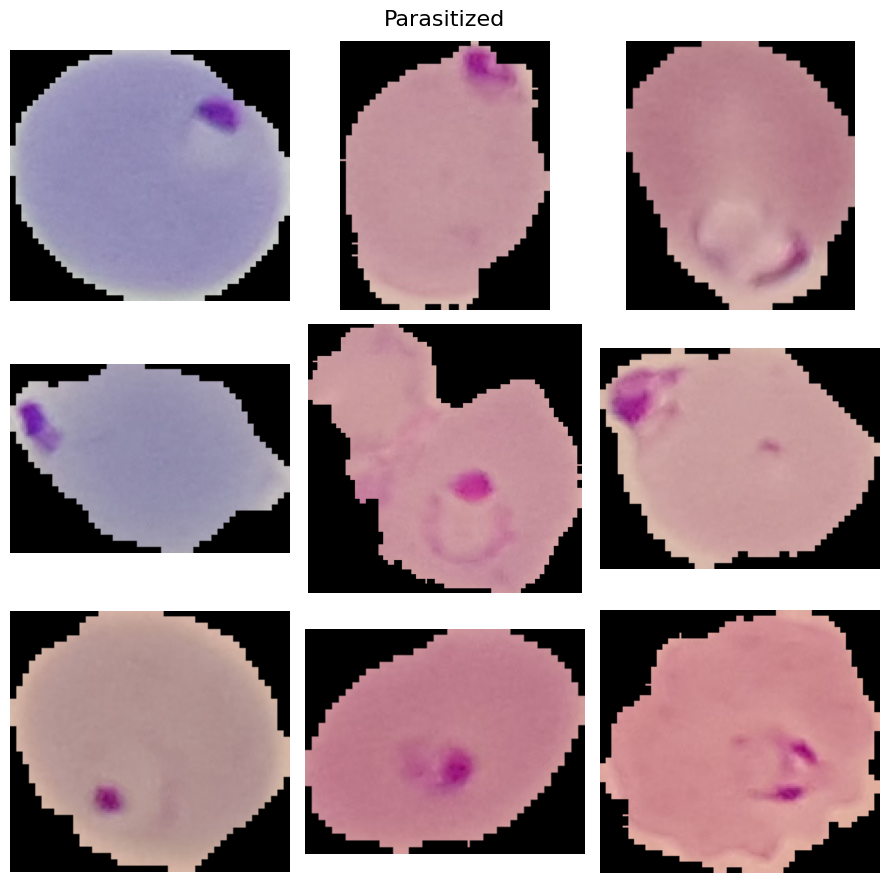

In [30]:
display_random_images(EXTRACT_DIR / "Parasitized")

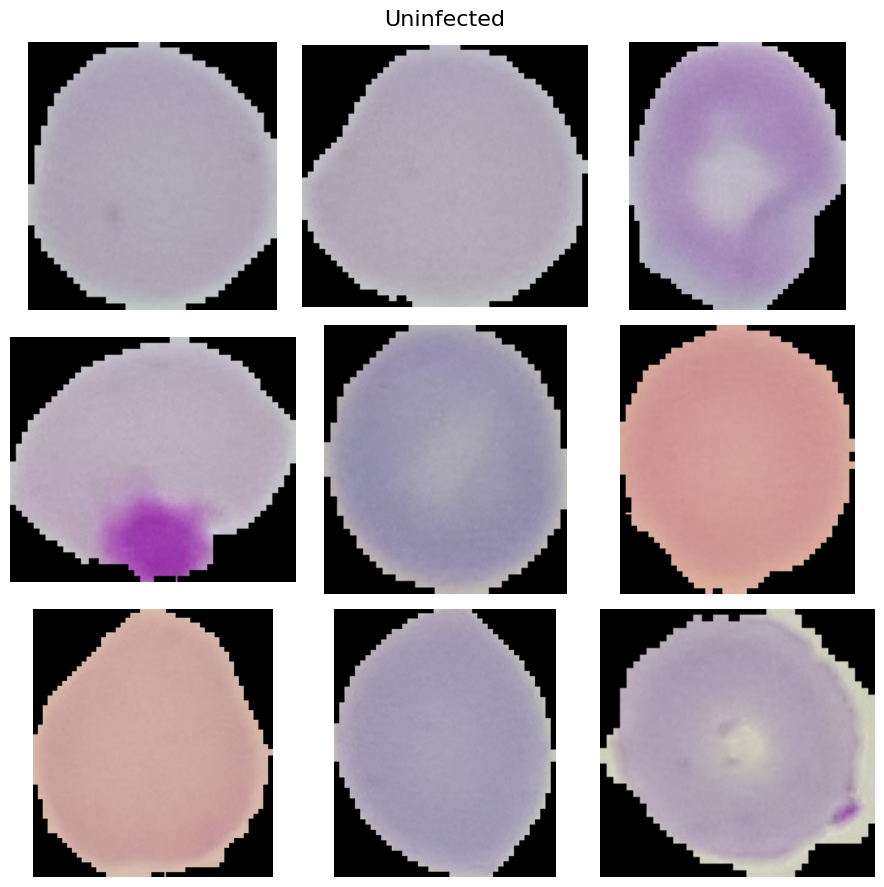

In [31]:
display_random_images(EXTRACT_DIR / "Uninfected")

## 8. Corrupted Image Detection

Machine learning pipelines assume that every image file can be opened successfully.

Corrupted files may interrupt training or evaluation. We therefore verify every image in the dataset by attempting to load it with Pillow.

In [32]:


# ============================================================
# Check for Corrupted Images
# ============================================================

VALID_EXTENSIONS = {".png", ".jpg", ".jpeg"}

corrupted_images = []

for class_folder in EXTRACT_DIR.iterdir():

    if not class_folder.is_dir():
        continue

    for image_path in class_folder.iterdir():

        if (
            not image_path.is_file()
            or image_path.suffix.lower() not in VALID_EXTENSIONS
        ):
            continue

        try:
            with Image.open(image_path) as img:
                img.verify()

        except Exception:
            corrupted_images.append(image_path)

print(f"Corrupted Images Found: {len(corrupted_images)}")

if corrupted_images:

    print("\nCorrupted Files")
    print("-" * 30)

    for file in corrupted_images:
        print(file)
else:
    print("No corrupted images detected.")

Corrupted Images Found: 0
No corrupted images detected.


## 9. Duplicate Image Detection

Duplicate images can bias model evaluation, particularly if identical images appear in different dataset splits.

To detect duplicates, we compute a hash for each image file and identify files with identical content.

In [33]:
import hashlib
from collections import defaultdict

# ============================================================
# Check for Duplicate Images
# ============================================================

VALID_EXTENSIONS = {".png", ".jpg", ".jpeg"}

hash_dict = defaultdict(list)

for class_folder in EXTRACT_DIR.iterdir():

    if not class_folder.is_dir():
        continue

    for image_path in class_folder.iterdir():

        if (
            not image_path.is_file()
            or image_path.suffix.lower() not in VALID_EXTENSIONS
        ):
            continue

        with open(image_path, "rb") as file:

            file_hash = hashlib.md5(
                file.read()
            ).hexdigest()

        hash_dict[file_hash].append(image_path)

duplicates = {
    file_hash: files
    for file_hash, files in hash_dict.items()
    if len(files) > 1
}

print(f"Duplicate Groups Found: {len(duplicates)}")

if duplicates:

    print("\nDuplicate Files")
    print("-" * 30)

    for i, (_, files) in enumerate(duplicates.items(), start=1):

        print(f"\nGroup {i}")

        for file in files:
            print(file)

else:
    print("No duplicate images detected.")

KeyboardInterrupt: 

# Data Understanding Summary

The malaria cell image dataset was inspected to assess its suitability for image classification.

## Dataset Structure

- The dataset contains two classes:
  - Parasitized
  - Uninfected
- Images are organized using a standard class-folder hierarchy.

## Class Distribution

- The dataset is balanced, with approximately equal numbers of parasitized and uninfected cell images.
- No class balancing techniques are anticipated during model training.

## Image Formats

- All images are stored in PNG format.
- Two non-image (`.db`) files were identified and will be ignored during preprocessing.

## Image Dimensions

- Images exhibit considerable variation in size.
- A total of 1,627 unique image dimensions were observed.
- Most images are concentrated around 120–140 pixels in both width and height.
- Images will therefore be resized to a common resolution before training.

## Color Channels

- Every image is stored in RGB format.
- RGB information will be preserved since staining patterns provide important diagnostic features.

## Image Quality

Visual inspection indicates that:

- Images are generally well focused.
- Cells are mostly centered.
- Backgrounds are clean.
- Cell boundaries are well defined.
- Parasites are clearly visible in infected samples.
- No obvious labeling inconsistencies were observed in the sampled images.

## Data Quality

- No corrupted image files were detected.
- No duplicate images were detected.

Overall, the dataset is of high quality and suitable for developing deep learning models for binary malaria cell classification.